# Topic 5, Example 3: Convolution of two continuous functions

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
# Course utilities (do not modify this cell)        
import sys
import os
base_path = os.path.expanduser("~/Documents/GitHub/Signals_and_Systems")
sys.path.insert(0, base_path)
sys.path.insert(0, os.path.join(base_path, "courseutils"))

import basic_material as bm
print("Basic Material version:", bm.__version__)
bm.setup_environment()


Basic Material version: 16.002-0.1


In [3]:
colors = bm.get_colors()
import numpy as np
import scipy
import matplotlib.pyplot as plt
from matplotlib import animation
from matplotlib.lines import Line2D
from matplotlib.offsetbox import AnchoredText
import sympy as sp
from sympy import Symbol, oo, integrate, Piecewise, Heaviside, DiracDelta, exp, I, pi, simplify

from ipywidgets import interactive
from IPython.display import HTML


In [4]:
# plotting time period
NN = 1000
ts = Symbol('t')

## Define two functions to convolve

In [5]:
def convolve(f, g, t, lower_limit=-oo, upper_limit=oo):
    tau = Symbol('__pick_a_name__', real=True)
    return integrate(f.subs(t, tau) * g.subs(t, t - tau), (tau, lower_limit, upper_limit))

def H(t):
    return np.heaviside(t, 1)

* For the system with impulse response $\Large g(t) = \alpha e^{-\alpha t}H(t)$

* Convolve with the input $\Large w(t) = H(t) - 2H(t-\tau)$ 

In [6]:
tt = np.linspace(-1,10, NN)
tau = 5
alpha = 2

w = Heaviside(ts) - 2 * Heaviside(ts - tau)
g = alpha*exp(-alpha*ts)*Heaviside(ts)
f3 = convolve(w, g, ts, 0 ,ts)

#modules = [{'Heaviside': lambda x: np.heaviside(x, 1)}, 'numpy']
modules = ['numpy']

lam_w = sp.lambdify(ts, w, modules=modules)
lam_g = sp.lambdify(ts, g, modules=modules)
lam_f3 = sp.lambdify(ts, simplify(f3), modules=modules)

In [7]:
# Analytic solution for the convolution integral
g_notes = (1-np.exp(-alpha*tt))*H(tt) - 2*(1-np.exp(-alpha*(tt-tau)))*H(tt-tau)

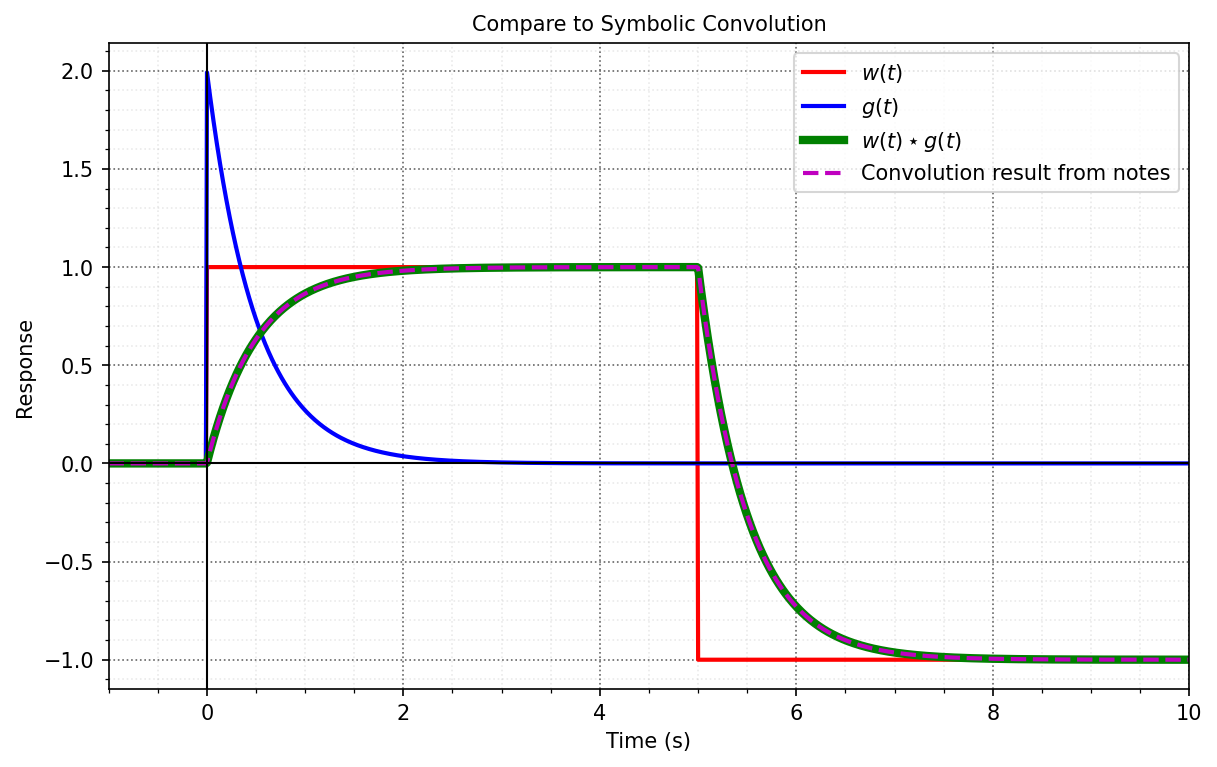

In [8]:
fig = plt.figure(figsize=(8, 5),dpi=150,constrained_layout = True)
plt.plot(tt, lam_w(tt),'r-',linewidth=2,label='$w(t)$')
plt.plot(tt, lam_g(tt),'b-',linewidth=2,label='$g(t)$')
plt.plot(tt, lam_f3(tt),'g',linewidth=4,label='$w(t)\star g(t)$')
plt.plot(tt, g_notes,'m--',linewidth=2,label='Convolution result from notes')

bm.nicegrid()
plt.legend()
plt.xlim(min(tt),max(tt))
plt.xlabel('Time (s)')
plt.ylabel('Response')
plt.title('Compare to Symbolic Convolution')
plt.savefig('figs/Topic5_ex3.pdf',format='pdf',dpi=300)
plt.show()

In [9]:
import matplotlib.pyplot as plt
from pptx import Presentation
from pptx.util import Inches

# Create figure
plt.plot([1,2,3,4], [1,4,9,16])
plt.title("Example Plot")
plt.savefig("plot.png", bbox_inches="tight")
plt.close()

# Create PowerPoint
prs = Presentation()

slide = prs.slides.add_slide(prs.slide_layouts[5])

slide.shapes.add_picture(
    "plot.png",
    Inches(1),    # left
    Inches(1),    # top
    width=Inches(6)
)

prs.save("lecture.pptx")

In [10]:
from pptx import Presentation
from pptx.util import Inches, Pt
from pptx.oxml.xmlchemy import OxmlElement
from datetime import datetime
import matplotlib.pyplot as plt


# --------------------------------------------------
# Bullet helper
# --------------------------------------------------
def set_bullet(paragraph, char="•", indent=18, hanging=12):

    pPr = paragraph._p.get_or_add_pPr()

    # remove existing bullet settings
    for tag in ("a:buChar", "a:buAutoNum", "a:buNone"):
        for e in pPr.findall(tag, pPr.nsmap):
            pPr.remove(e)

    buChar = OxmlElement("a:buChar")
    buChar.set("char", char)
    pPr.append(buChar)

    # PowerPoint uses EMUs
    pPr.set("marL", str(int(indent * 12700)))
    pPr.set("indent", str(int(-hanging * 12700)))


# --------------------------------------------------
# Create figure
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(5, 3))

ax.plot([0, 1, 2, 3], [0, 1, 4, 9])
ax.set_title("Example Figure")
ax.grid(True)

figfile = "figure.png"
plt.savefig(figfile, bbox_inches="tight")
plt.close(fig)

# --------------------------------------------------
# Create presentation
# --------------------------------------------------
prs = Presentation()

slide = prs.slides.add_slide(prs.slide_layouts[6])

# --------------------------------------------------
# Title
# --------------------------------------------------
title_box = slide.shapes.add_textbox(
    Inches(0.3),
    Inches(0.15),
    Inches(9.0),
    Inches(0.5)
)

p = title_box.text_frame.paragraphs[0]
p.text = "System Performance Results"
p.font.size = Pt(24)
p.font.bold = True

# --------------------------------------------------
# Left text box
# --------------------------------------------------
bullet_box = slide.shapes.add_textbox(
    Inches(0.3),
    Inches(0.8),
    Inches(3.5),
    Inches(4.5)
)

tf = bullet_box.text_frame
tf.clear()

bullets = [
    ("major", "Controller Design"),
    ("minor", "Phase margin target = 60 deg"),
    ("minor", "Crossover frequency = 5 rad/s"),

    ("major", "Simulation Results"),
    ("minor", "Rise time = 0.4 s"),
    ("minor", "Overshoot = 8%"),
]

for i, (kind, text) in enumerate(bullets):

    p = tf.paragraphs[0] if i == 0 else tf.add_paragraph()

    if kind == "major":
        p.text = f"• {text}"
        p.font.size = Pt(20)
        p.font.bold = True
        p.level = 0

    else:
        p.text = f"   – {text}"
        p.font.size = Pt(16)
        p.level = 0

# --------------------------------------------------
# Figure on right
# --------------------------------------------------
slide.shapes.add_picture(
    figfile,
    Inches(4.1),
    Inches(0.8),
    width=Inches(5.4)
)

# --------------------------------------------------
# Date bottom left
# --------------------------------------------------
date_box = slide.shapes.add_textbox(
    Inches(0.3),
    Inches(6.8),
    Inches(2.5),
    Inches(0.25)
)

p = date_box.text_frame.paragraphs[0]
p.text = datetime.now().strftime("%Y-%m-%d")
p.font.size = Pt(8)

# --------------------------------------------------
# Save
# --------------------------------------------------
prs.save("example_presentation.pptx")

In [11]:
from pptx.util import Inches, Pt
from datetime import datetime


def add_figure_slide(
    prs,
    title,
    figure,
    bullets,
    date=None,
):
    """
    Add slide with:
        title at top
        bullets on left half
        figure on right half

    Parameters
    ----------
    prs : Presentation
    title : str
    figure : str
        png/jpg filename
    bullets : list

        [
            ("Major bullet 1",
                ["minor 1", "minor 2"]),
            ("Major bullet 2",
                ["minor 1", "minor 2"]),
        ]

    date : str or None
    """

    slide = prs.slides.add_slide(prs.slide_layouts[6])

    # ---------------------------------------
    # Layout constants
    # ---------------------------------------

    left_margin = 0.30
    right_margin = 0.30

    title_top = 0.15
    title_height = 0.50

    content_top = 0.80
    content_height = 5.80

    slide_width = 10.0
    half_width = (slide_width - left_margin - right_margin) / 2

    # ---------------------------------------
    # Title
    # ---------------------------------------

    title_box = slide.shapes.add_textbox(
        Inches(left_margin),
        Inches(title_top),
        Inches(slide_width),
        Inches(title_height),
    )

    p = title_box.text_frame.paragraphs[0]
    p.text = title
    p.font.size = Pt(24)
    p.font.bold = True

    # ---------------------------------------
    # Bullets
    # ---------------------------------------

    bullet_box = slide.shapes.add_textbox(
        Inches(left_margin),
        Inches(content_top),
        Inches(half_width - 0.15),
        Inches(content_height),
    )

    tf = bullet_box.text_frame
    tf.clear()

    first = True

    for major, minors in bullets:

        if first:
            p = tf.paragraphs[0]
            first = False
        else:
            p = tf.add_paragraph()

        p.text = f"• {major}"
        p.font.size = Pt(20)
        p.font.bold = True
        p.space_before = Pt(6)

        for item in minors:

            p = tf.add_paragraph()
            p.text = f"   – {item}"
            p.font.size = Pt(16)

    # ---------------------------------------
    # Figure
    # ---------------------------------------

    slide.shapes.add_picture(
        figure,
        Inches(left_margin + half_width),
        Inches(content_top),
        width=Inches(half_width),
    )

    # ---------------------------------------
    # Date
    # ---------------------------------------

    if date is None:
        date = datetime.now().strftime("%Y-%m-%d")

    date_box = slide.shapes.add_textbox(
        Inches(left_margin),
        Inches(6.8),
        Inches(2.5),
        Inches(0.2),
    )

    p = date_box.text_frame.paragraphs[0]
    p.text = date
    p.font.size = Pt(8)

    return slide

In [12]:
from pptx import Presentation

prs = Presentation()

add_figure_slide(
    prs,
    title="System Performance Results",
    figure="figure.png",
    bullets=[
        ("Controller Design", [
            "Phase margin target = 60 deg",
            "Crossover frequency = 5 rad/s",
        ]),
        ("Simulation Results", [
            "Rise time = 0.4 s",
            "Overshoot = 8%",
            "Steady state error ≈ 0",
        ]),
    ]
)

prs.save("example_presentation.pptx")